# Ссылки


Ноутбуки
https://cloud.mail.ru/public/4tHq/JWVATN2NP

Данные
https://cloud.mail.ru/public/QM6Z/xrCSGqoQS

Данные на gdrive
url = "https://drive.google.com/file/d/1ncNsjwV38V9lLZc3PBLTwjNML9R901qX/view?usp=sharing"

In [ ]:
!pip install -q gdown

import gdown

url = "https://drive.google.com/file/d/1ncNsjwV38V9lLZc3PBLTwjNML9R901qX/view?usp=sharing"
output = "drom_used_cars.csv"

gdown.download(url=url, output=output, quiet=False, fuzzy=True)

import pandas as pd
df = pd.read_csv(output)
df.head()

In [16]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# DATA (drom_used_cars)

| Столбец | Описание |
|---|---|
| `listing_id` | Уникальный идентификатор объявления на Drom. |
| `brand` | Марка автомобиля: BMW, Chery, Lada и т. д. |
| `brand_group` | Группа марки: `Europe`, `China`, `Russia`. |
| `brand_country` | Страна происхождения марки, а не сборки автомобиля. |
| `model` | Модель автомобиля, например Tiguan. |
| `year` | Год выпуска. |
| `engine_volume_l` | Объём двигателя в литрах. |
| `power_hp` | Мощность двигателя в лошадиных силах. |
| `fuel_type` | Тип топлива или силовой установки: бензин, дизель, гибрид, электро и т. д. |
| `transmission` | Коробка передач: механика, АКПП, робот, вариатор. |
| `drive` | Привод: передний, задний, `4WD` — полный. |
| `mileage_km` | Пробег в километрах. |
| `body_type` | Тип кузова: седан, хэтчбек, внедорожник и т. д. |
| `trim` | Модификация и комплектация, указанные в объявлении. |
| `city` | Город объявления: Москва или Санкт-Петербург. |
| `price_rub` | **Цена предложения продавца в рублях**. Фактическая сумма сделки неизвестна. |
| `price_type` | Тип цены: `asking_price` — запрашиваемая продавцом цена. |
| `condition` | Категория автомобиля: `used` — с пробегом. |
| `is_damaged` | `1` — есть отметка о повреждении; `0` — такой отметки нет. Ноль не гарантирует отсутствие повреждений. |
| `labels` | Дополнительные отметки Drom, например «от собственника», «без пробега по РФ». |
| `attributes_raw` | Исходный текст характеристик из выдачи Drom. |
| `source_url` | Ссылка на конкретное объявление. |
| `search_url` | Страница выдачи, с которой скачано объявление. |
| `collected_at_utc` | Дата и время скачивания страницы в UTC, а не дата публикации объявления. |
| `model_rank` | Место модели внутри марки: от 1 до 5 по суммарному числу объявлений с пробегом в двух городах на момент отбора. |
| `model_id` | Идентификатор модели в каталоге Drom. |

In [28]:
DATA_PATH = 'data/drom_used_cars.csv'
TARGET_COL = 'price_rub'

df = pd.read_csv(DATA_PATH)
print('Исходный размер датасета', df.shape)

TARGET_COL = 'price_rub'
DROP_COLS = ['listing_id', 
'source_url', 
'search_url', 
'model_rank', 
'model_id', 
'collected_at_utc',
'price_type',
'condition',
'labels',
'trim',
'year']

# Преобразования столбцов (target, age, transmission)

df[TARGET_COL] = df[TARGET_COL]/1000000

df['age'] = 2026 - df['year']

transmission_dict = {'робот': 'автомат',
                     'АКПП': 'автомат',
                     'вариатор': 'автомат'
                    }
df['transmission_type'] = df['transmission'].replace(transmission_dict)

# Удаляем некорректные данные (УАЗ буханка, веста, Mercedes-Benz G Class электро и ГАЗ)
df = df[df['engine_volume_l']<6.5]

df = df.drop(columns=DROP_COLS)
df = df.dropna()
print('Размер датасета после удаления пропущенных значений', df.shape)

num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [x for x in num_cols if x!= TARGET_COL]
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()
print('\nЧисловые признаки', num_cols)
print('Категориальные признаки', cat_cols)

Исходный размер датасета (8709, 26)
Размер датасета после удаления пропущенных значений (8560, 17)

Числовые признаки ['engine_volume_l', 'power_hp', 'mileage_km', 'is_damaged', 'age']
Категориальные признаки ['brand', 'brand_group', 'brand_country', 'model', 'fuel_type', 'transmission', 'drive', 'body_type', 'city', 'attributes_raw', 'transmission_type']


In [18]:
df.head(4)

,brand,brand_group,brand_country,model,engine_volume_l,power_hp,fuel_type,transmission,drive,mileage_km,body_type,city,price_rub,is_damaged,attributes_raw,age,transmission_type
0,Volkswagen,Europe,Germany,Tiguan,2.0,180.0,бензин,робот,4WD,70000,SUV или внедорожник,Москва,2.800,0,2.0 л (180 л.с.) | бензин | робот | 4WD | 70 0...,5,автомат
1,Volkswagen,Europe,Germany,Tiguan,2.0,180.0,бензин,робот,4WD,88880,SUV или внедорожник,Санкт-Петербург,2.990,0,2.0 л (180 л.с.) | бензин | робот | 4WD | 88 8...,5,автомат
2,Volkswagen,Europe,Germany,Tiguan,2.0,170.0,бензин,АКПП,4WD,226000,SUV или внедорожник,Москва,1.350,0,2.0 л (170 л.с.) | бензин | АКПП | 4WD | 226 0...,14,автомат
3,Volkswagen,Europe,Germany,Tiguan,2.0,170.0,бензин,АКПП,4WD,227000,SUV или внедорожник,Санкт-Петербург,0.849,0,2.0 л (170 л.с.) | бензин | АКПП | 4WD | 227 0...,16,автомат


# Boxplot 

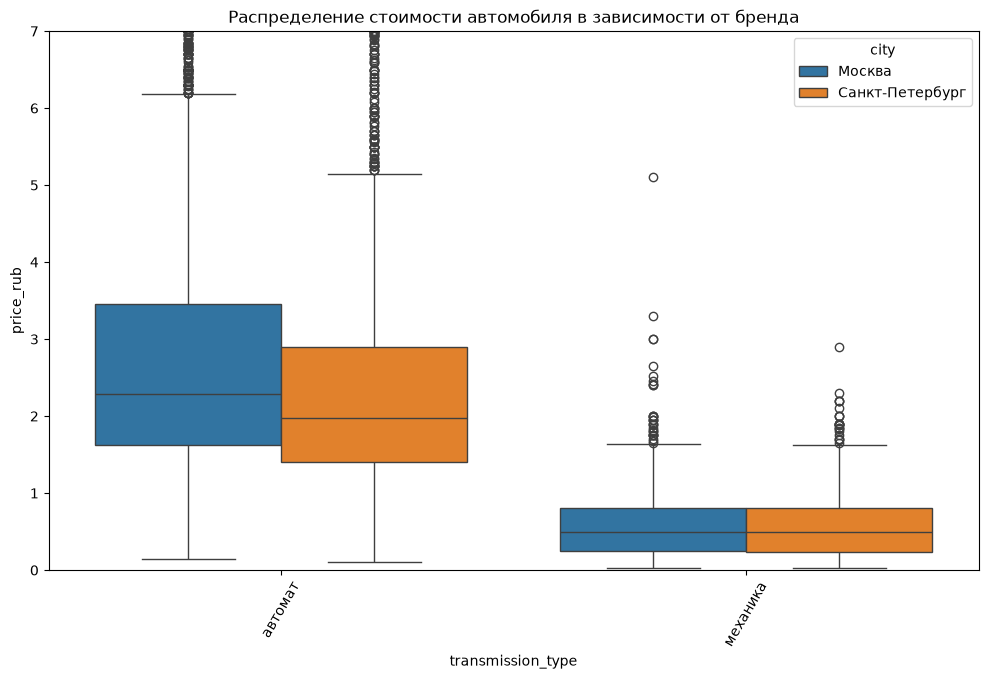

In [29]:
f, ax = plt.subplots(figsize=(12,7))
ax.set_title('Распределение стоимости автомобиля в зависимости от бренда')
sns.boxplot(data=df, x='transmission_type', y='price_rub', hue='city', whis=1.5, ax=ax)
plt.xticks(rotation=60)
ax.set_ylim([0,7])
plt.show()



# Энкодеры

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df, df[TARGET_COL], test_size=0.2, random_state=12)

In [ ]:
from category_encoders import OrdinalEncoder, OneHotEncoder, TargetEncoder, CountEncoder

ord = OrdinalEncoder()
ord.fit(X_train['drive'])
display(ord.transform(X_train['drive']))


ohe = OneHotEncoder(handle_unknown=0)
ohe.fit_transform(X_train['brand'])
display(ohe.transform(X_train['brand']))

print('value_counts', X_train['fuel_type'].value_counts())
cenc = CountEncoder(cols=["fuel_type"])
cenc.fit_transform(X_train['fuel_type'])
display(cenc.transform(X_train['fuel_type']))


# OneHotEncoder sklearn
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop='first', 
                    handle_unknown='ignore', 
                    sparse_output=False
                    )


X_train_ohe = ohe.fit_transform(X_train[['drive']])
features = ohe.get_feature_names_out().tolist()
pd.DataFrame(X_train_ohe, columns = features)

,drive
4561,1
6597,1
3203,1
5185,2
8432,2
...,...
281,2
3749,1
7523,2
3357,2


,brand_1,brand_2,brand_3,brand_4,brand_5,brand_6,brand_7,brand_8,brand_9,brand_10,brand_11,brand_12,brand_13
4561,1,0,0,0,0,0,0,0,0,0,0,0,0
6597,0,1,0,0,0,0,0,0,0,0,0,0,0
3203,0,0,1,0,0,0,0,0,0,0,0,0,0
5185,0,0,0,1,0,0,0,0,0,0,0,0,0
8432,0,0,0,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
281,0,0,0,0,0,0,1,0,0,0,0,0,0
3749,0,0,1,0,0,0,0,0,0,0,0,0,0
7523,0,0,0,0,1,0,0,0,0,0,0,0,0
3357,0,0,1,0,0,0,0,0,0,0,0,0,0


value_counts fuel_type
бензин    5850
дизель     762
гибрид     236
Name: count, dtype: int64


,fuel_type
4561,5850
6597,5850
3203,762
5185,5850
8432,5850
...,...
281,5850
3749,762
7523,5850
3357,5850


,drive_задний,drive_передний
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,1.0
4,0.0,1.0
...,...,...
6843,0.0,1.0
6844,0.0,0.0
6845,0.0,1.0
6846,0.0,1.0


# Качество моделей

In [38]:
def calculate_metrics(y_test, y_pred, y_train, y_pred_train):
    metrics = {
        "train_rmse": root_mean_squared_error(y_train, y_pred_train),
        "test_rmse": root_mean_squared_error(y_test, y_pred),
        "train_mae": mean_absolute_error(y_train, y_pred_train),
        "test_mae": mean_absolute_error(y_test, y_pred),
        "train_mape": mean_absolute_percentage_error(y_train, y_pred_train),
        "test_mape": mean_absolute_percentage_error(y_test, y_pred),
        "train_r2": r2_score(y_train, y_pred_train),
        "test_r2": r2_score(y_test, y_pred)
    }

    return pd.DataFrame({'train': [metrics['train_rmse'], metrics['train_mae'], metrics['train_mape'], metrics['train_r2']],
                         'test': [metrics['test_rmse'], metrics['test_mae'], metrics['test_mape'], metrics['test_r2']]},
                        index=['RMSE', 'MAE', 'MAPE', 'R2']).round(3)


In [39]:
def prepare_features(X_train, X_test, num_cols, cat_cols_subset):
    
    sc = StandardScaler()
    enc = OneHotEncoder(drop='first', 
                        handle_unknown='ignore', 
                        sparse_output=False
                        )

    X_train_scaled_num = sc.fit_transform(X_train[num_cols])
    X_train_scaled_cat = enc.fit_transform(X_train[cat_cols_subset])
  
    X_train_scaled = np.concat([X_train_scaled_num, X_train_scaled_cat], axis=1)


    X_test_scaled_num = sc.transform(X_test[num_cols])
    X_test_scaled_cat = enc.transform(X_test[cat_cols_subset])

    X_test_scaled = np.concat([X_test_scaled_num, X_test_scaled_cat], axis=1)

    return X_train_scaled, X_test_scaled

# Выбор гиперпараметра
# Пример написания кода без cross_validate и pipeline

Найдем лучшее значение параметра alpha модели Ridge оцененного по качеству на кросс-валидации

In [41]:
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error 


alphas = [
    0.1, 1, 10, 30, 50, 100, 1000, 2000, 3000, 4000,
    4200, 4500, 4800, 5000, 6000, 7000, 8000, 9000,
    10000, 20000, 30000
]
cat_cols_subset = ['brand']
cols = num_cols + cat_cols_subset
X_train, X_test, y_train, y_test = train_test_split(df[cols], df[TARGET_COL], test_size=.2, random_state=42)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

Ridge_results = [] 

for alpha in alphas:

    results = []
    for fold, (train_idx, test_idx) in enumerate(cv.split(X_train)):
        # получаем train/test
        fold_Xtrain, fold_ytrain = X_train.iloc[train_idx], y_train.iloc[train_idx]
        fold_Xtest, fold_ytest = X_train.iloc[test_idx], y_train.iloc[test_idx]    

        # задаем модель
        model = Ridge(alpha=alpha)

        # предобработка признаков - scaler + encoder
        fold_X_train_scaled, fold_X_test_scaled = prepare_features(fold_Xtrain, fold_Xtest, num_cols, cat_cols_subset)                

        # обучение + оценка предсказания
        model.fit(fold_X_train_scaled, fold_ytrain)
        fold_y_pred = model.predict(fold_X_test_scaled)
        results.append(calculate_metrics(fold_ytest, fold_y_pred, 
                                        fold_ytrain, model.predict(fold_X_train_scaled)))  


    # агрегация полученных метрик на фолдах до средних и std
    results = pd.concat(results).reset_index()       
    tmp = results.groupby('index').agg(train_mean=('train', 'mean'),
                                train_std=('train', 'std'),
                                test_mean=('test', 'mean'),
                                test_std=('test', 'std')
    )  
    # добавляем значение гиперпараметра модели для идентификации
    tmp['alpha'] = alpha

    # добавляем результаты оценки модели на кросс-валидации
    Ridge_results.append(tmp)

# Отсортируем результаты по метрике и среднему ее значению на тесте
Ridge_results = pd.concat(Ridge_results).reset_index()  
Ridge_results.sort_values(['index', 'test_mean'])

,index,train_mean,train_std,test_mean,test_std,alpha
20,MAE,1.1232,0.021673,1.1266,0.039074,100.0
16,MAE,1.1264,0.022434,1.1302,0.035060,50.0
12,MAE,1.1304,0.022876,1.1342,0.032942,30.0
8,MAE,1.1398,0.024004,1.1436,0.031085,10.0
4,MAE,1.1472,0.024631,1.1514,0.030811,1.0
...,...,...,...,...,...,...
67,RMSE,2.7782,0.061137,2.7676,0.309223,8000.0
71,RMSE,2.8156,0.061647,2.8046,0.311097,9000.0
75,RMSE,2.8506,0.062416,2.8392,0.312419,10000.0
79,RMSE,3.0956,0.065961,3.0846,0.316410,20000.0


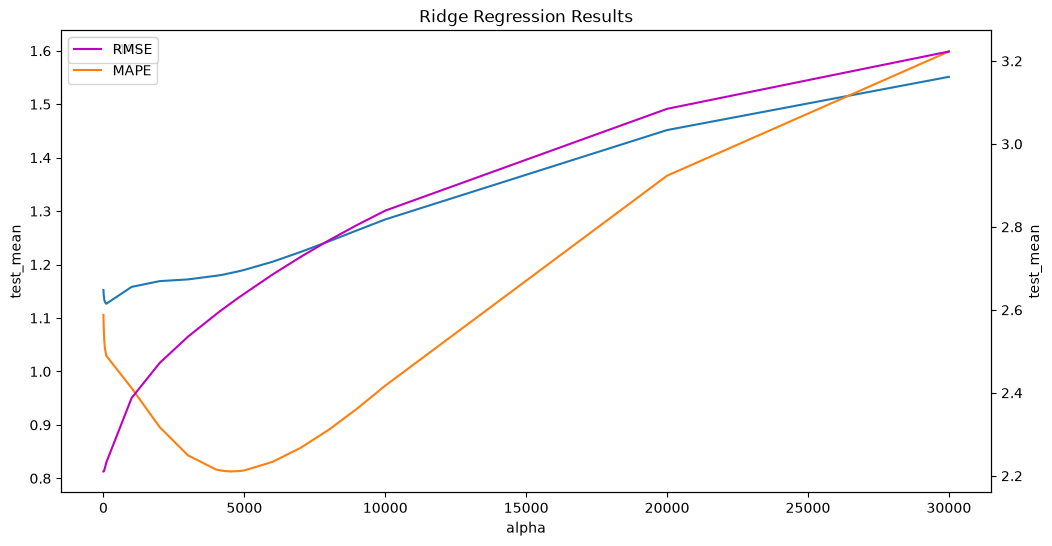

In [42]:
f, zx = plt.subplots(figsize=(12,6))
zx.set_title('Ridge Regression Results')

ax = zx.twinx() 
sns.lineplot(data=Ridge_results[Ridge_results['index']=='RMSE'], x='alpha', y='test_mean', label='RMSE', c='m', ax=ax)
for mtr in ['MAE',  'MAPE']:
    sns.lineplot(data=Ridge_results[Ridge_results['index']==mtr], x='alpha', y='test_mean', label=mtr, ax=zx)

plt.legend()
plt.show()

# Итоговая оценка качества

2 возможных итоговых варианта:
1) обучить 1 модель на всех данных
2) оставить N моделей и в качестве предсказания брать среднее



In [44]:
model = Ridge(alpha=100)


X_train_scaled, X_test_scaled = prepare_features(X_train, 
                                                 X_test, 
                                                 num_cols,
                                                 cat_cols_subset)                



model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
results=calculate_metrics(y_test, y_pred, 
                                y_train, model.predict(X_train_scaled)) 

results

,train,test
RMSE,2.226,1.970
MAE,1.124,1.072
MAPE,1.029,0.912
R2,0.639,0.621


# Реализация с помощью Pipeline и GridSearchCV

In [47]:
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate

alphas_pipeline = [
    0.1, 1, 10, 30, 50, 100, 1000, 2000, 3000, 4000,
    4200, 4500, 4800, 5000, 6000, 7000, 8000, 9000,
    10000, 20000, 30000
]
#cv = KFold(n_splits=5, shuffle=True, random_state=42)

preprocessor = ColumnTransformer(transformers = [('num', StandardScaler(), num_cols),
                                                ('cat', OneHotEncoder(drop='first', 
                                                                    handle_unknown='ignore', 
                                                                    sparse_output=False), cat_cols_subset)])

ridge_pipe = Pipeline([('preprocessor', preprocessor),
                        ('ridge', Ridge())
                        ])

search = GridSearchCV(estimator=ridge_pipe,
                      param_grid={'ridge__alpha': alphas_pipeline},
                      scoring='neg_mean_absolute_error',
                      cv=cv,
                      refit=True,
                      return_train_score=True)

search.fit(X_train, y_train)

search_results = pd.DataFrame(search.cv_results_)
search_results = search_results[['param_ridge__alpha', 'mean_test_score', 'std_test_score']]
display(search_results)

print('Best params', search.best_params_)
print('Best score', -search.best_score_)

best_pipe = search.best_estimator_
y_pred = best_pipe.predict(X_test)
print('Test MAE:', mean_absolute_error(y_test, y_pred))

,param_ridge__alpha,mean_test_score,std_test_score
0,0.1,-1.126631,0.021814
1,1.0,-1.125625,0.021861
2,10.0,-1.117348,0.022555
3,30.0,-1.105392,0.024690
4,50.0,-1.097819,0.026528
5,100.0,-1.087928,0.030234
6,1000.0,-1.134255,0.044106
7,2000.0,-1.158789,0.044368
8,3000.0,-1.165761,0.045892
9,4000.0,-1.172001,0.047559


Best params {'ridge__alpha': 100}
Best score 1.0879279433279476
Test MAE: 1.029616343806948


# Итоговый подбор лучшей модели


Среди моделей Ridge, Lasso, ElasticNet выберем лучшую с подбором гиперпараметра alpha

In [48]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
best_score = 100000

alphas_pipeline = [0.001, 0.001, 0.1, 0.2, 0.5,0.55, 0.56, 0.57, 0.58, 0.59, 0.6, 0.61, 0.62, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95,
    1, 10, 30, 50, 100, 1000, 2000, 3000, 4000,
    4200, 4500, 4800, 5000, 6000, 7000, 8000, 9000,
    10000, 20000, 30000
]
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cat1_cols_subset = []
cat2_cols_subset = ['fuel_type', 'transmission_type', 'brand', 'drive']
cat3_cols_subset = []

cat_cols_subset = cat1_cols_subset + cat2_cols_subset + cat3_cols_subset
cols = num_cols + cat_cols_subset
X_train, X_test, y_train, y_test = train_test_split(df[cols], df[TARGET_COL], test_size=.2, random_state=42)


preprocessor = ColumnTransformer(transformers = [('num', StandardScaler(), num_cols),
                                                ('cat1', OrdinalEncoder(), cat1_cols_subset),
                                                ('cat2', OneHotEncoder(drop='first', 
                                                                        handle_unknown='ignore', 
                                                                        sparse_output=False), cat2_cols_subset),
                                                ('cat3', TargetEncoder(), cat3_cols_subset)])

for model in [Ridge(),  ElasticNet(), Lasso()]:

    pipe = Pipeline([('preprocessor', preprocessor),
                            ('model', model)
                            ])
    param_grid = {
        'model__alpha': alphas_pipeline,
    }

    search = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring='neg_mean_absolute_error',
        cv=cv,
        refit=True,
        return_train_score=True,
    )

    search.fit(X_train, y_train)

    print(f'{model.__class__.__name__}')
    print('Лучший alpha:', search.best_params_)
    print('Лучший CV MAE:', -search.best_score_)
    print('\n')

    if -search.best_score_ < best_score:
        best_score = search.best_score_
        best_model = search.best_estimator_
        y_pred_grid = search.best_estimator_.predict(X_test)


print(f'BEST MODEL TEST {best_model.steps[-1][-1].__class__.__name__}')
print('Test RMSE:', root_mean_squared_error(y_test, y_pred_grid))
print('Test MAE:', mean_absolute_error(y_test, y_pred_grid))



Ridge
Лучший alpha: {'model__alpha': 100}
Лучший CV MAE: 1.0879279433279476


ElasticNet
Лучший alpha: {'model__alpha': 0.001}
Лучший CV MAE: 1.1219968201408441


Lasso
Лучший alpha: {'model__alpha': 0.001}
Лучший CV MAE: 1.1229444965832271


BEST MODEL TEST Ridge
Test RMSE: 1.9055473877067295
Test MAE: 1.029616343806948


# SGDRegressor

 — это линейная регрессия, где коэффициенты ищутся не аналитически, а с помощью стохастического градиентного спуска.

Для него масштабирование признаков практически обязательно.

**Параметры:**

Loss:
- squared_error, 
- huber (ведёт себя как квадратичная ошибка для небольших residuals и примерно как абсолютная ошибка для больших)
- epsilon_insensitive $L=\max(0, |y-\hat y|-\epsilon)$ - если ошибка прогноза спроса ±$\epsilon$ единиц для бизнеса несущественна, мы можем явно сказать модели:
- squared_epsilon_insensitive - то же самое, но за пределами \(\epsilon\)-коридора штраф становится квадратичным

penalty - отвечает за регуляризацию (None, l1, l2, elasticnet)

learning_rate - 'constant', 'optimal', 'invscaling', 'adaptive'



Важная возможность — partial_fit позволяет работать с:
- streaming data;
- данными, которые не помещаются в RAM;
- постоянно приходящими наблюдениями;
- online learning.


## Когда стоит использовать:
- если датасет очень большой, 
- данные приходят потоком;
- обучение нужно выполнять частями. 

Для обычного небольшого датасета - `LinearRegression`

In [49]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import SGDRegressor

lr_mse = SGDRegressor(loss = 'squared_error', max_iter = 5000)
lr_mae = SGDRegressor(loss = 'epsilon_insensitive', epsilon = 0, max_iter = 5000)
lr_huber = SGDRegressor(loss = 'huber', max_iter = 5000)

lr_mse.fit(X_train_scaled, y_train)
lr_mae.fit(X_train_scaled, y_train)
lr_huber.fit(X_train_scaled, y_train)

y_pred_mse = lr_mse.predict(X_test_scaled)
y_pred_mae = lr_mae.predict(X_test_scaled)
y_pred_huber = lr_huber.predict(X_test_scaled)

print(f'MSE model MAE={mean_absolute_error(y_test, y_pred_mse)}')
print(f'MAE model MAE={mean_absolute_error(y_test, y_pred_mae)}')
print(f'HUBER model MAE={mean_absolute_error(y_test, y_pred_huber)}')
print()
print(f'MSE model RMSE={root_mean_squared_error(y_test, y_pred_mse)}')
print(f'MAE model RMSE={root_mean_squared_error(y_test, y_pred_mae)}')
print(f'HUBER model RMSE={root_mean_squared_error(y_test, y_pred_huber)}')

MSE model MAE=1.1028765375664729
MAE model MAE=0.8405677709987149
HUBER model MAE=0.9154593983391982

MSE model RMSE=1.9821234594646555
MAE model RMSE=2.1309843650673237
HUBER model RMSE=2.3845150465871283


## partial_fit

 Делает один проход по переданному батчу и обновляет коэффициенты модели. 
 
 Следующий вызов продолжает с уже найденных коэффициентов.

In [50]:
model_sgd = SGDRegressor(
    loss='squared_error',
    random_state=3,
    learning_rate='invscaling',
    eta0=0.01,
    tol=0.01
)

X = np.asarray(X_train_scaled)
y = np.asarray(y_train)

batch_size = 256
n_epochs = 5

for epoch in range(n_epochs):
    # Перемешиваем строки перед каждым проходом
    order = np.random.default_rng(13 + epoch).permutation(len(X))

    for start in range(0, len(X), batch_size):
        batch_idx = order[start:start + batch_size]
        model_sgd.partial_fit(X[batch_idx], y[batch_idx])

y_pred = model_sgd.predict(X_test_scaled)

print('RMSE:', root_mean_squared_error(y_test, y_pred))
print('MAE:', mean_absolute_error(y_test, y_pred))

RMSE: 1.9793069182113452
MAE: 1.0901140766477966


# LogisticRegression

LogisticRegression решает задачу классификации.
В бинарном случае: $y \in {0,1}$

Например:
- дефолт / нет дефолта;
- клиент уйдёт / не уйдёт;
- купит продукт / не купит;
- мошенническая транзакция / обычная;
- сделка состоится / не состоится.


Модель оценивает не просто класс, а вероятность:
$P(Y=1|X=x)$

То есть логистическая регрессия отвечает на вопрос:
«С какой вероятностью объект относится к классу 1 при данных значениях признаков?»

Математически:

$z=\beta_0+\beta_1x_1+\ldots+\beta_px_p$

и затем:

$p=P(Y=1|X) = \sigma(z) = \frac{1}{1+e^{-z}}.$



# LOG-LOSS


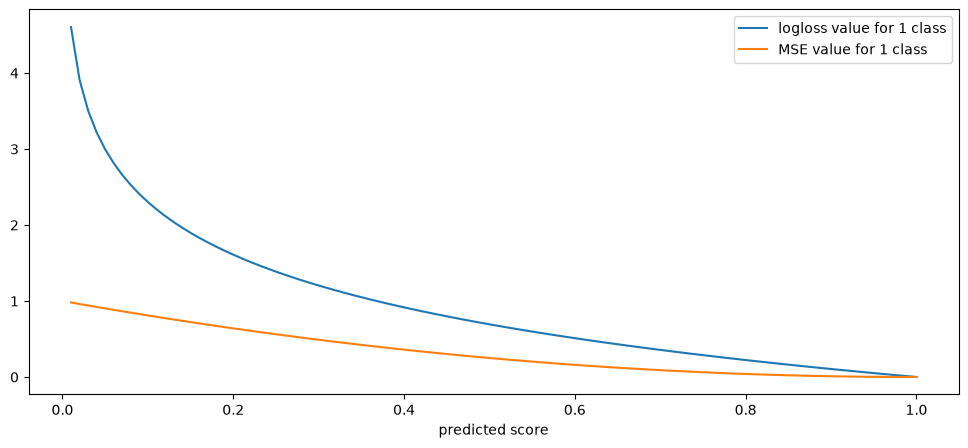

In [51]:
f, ax = plt.subplots(figsize=(12,5))

x = [x/100 for x in range(1,101)]

ax.set_title('')
plt.plot(x, -np.log(x), label='logloss value for 1 class')
plt.plot(x, [(y-1)**2 for y in x], label='MSE value for 1 class')

ax.set_xlabel('predicted score')
plt.legend()
plt.show()

# CLASSIFICATION METRICS

| Метрика | Формула / идея | Что измеряет | Когда полезна | Риски |
|---|---|---|---|---|
| **Accuracy** | ($\frac{TP+TN}{TP+TN+FP+FN}$\) | Долю правильных классификаций | Классы примерно сбалансированы, FP и FN стоят примерно одинаково | Может быть обманчиво высокой при дисбалансе классов |
| **Precision** | \($\frac{TP}{TP+FP}$\) | Среди предсказанных `1` — сколько действительно `1` | Когда дорог **False Positive** | Может быть высокой при низком Recall |
| **Recall** | \($\frac{TP}{TP+FN}$\) | Какую долю всех реальных `1` модель нашла | Когда дорог **False Negative** | Можно получить высокий Recall, почти всем ставя класс `1` |
| **F1-score** | \($2\frac{Precision\cdot Recall}{Precision+Recall}$\) | Баланс Precision и Recall | Несбалансированные классы, когда важны и FP, и FN | Игнорирует TN; не всегда лучшая бизнес-метрика |
| **ROC AUC** | $P(score_{+} > score_{-})$ | Качество **ранжирования** объектов | Когда важно отделять класс 1 от класса 0 независимо от threshold | Не показывает качество самих вероятностей; при сильном дисбалансе может выглядеть слишком оптимистично |
| **PR AUC** | Площадь под Precision–Recall curve | Качество ранжирования с фокусом на положительный класс | Когда класс `1` редкий: fraud, default, churn | Сильно зависит от доли поло

In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss

def calculate_metrics(y_test, y_pred, y_pred_proba, y_train, y_pred_train, y_pred_train_proba):
    metrics = {}

    metrics["Accuracy"] = accuracy_score(y_test, y_pred)
    metrics["Precision"] = precision_score(y_test, y_pred)
    metrics["Recall"] = recall_score(y_test, y_pred)
    metrics["F1-Score"] = f1_score(y_test, y_pred)
    metrics["ROC AUC"] = roc_auc_score(y_test, y_pred_proba)
    metrics["LogLoss"] = log_loss(y_test, y_pred_proba)

    test_metrics = pd.DataFrame(metrics, index=['Test']).T.round(3)

    metrics["Accuracy"] = accuracy_score(y_train, y_pred_train)
    metrics["Precision"] = precision_score(y_train, y_pred_train)
    metrics["Recall"] = recall_score(y_train, y_pred_train)
    metrics["F1-Score"] = f1_score(y_train, y_pred_train)
    metrics["ROC AUC"] = roc_auc_score(y_train, y_pred_train_proba)
    metrics["LogLoss"] = log_loss(y_train, y_pred_train_proba)

    train_metrics = pd.DataFrame(metrics, index=['Train']).T.round(3)
   
    return pd.concat([train_metrics, test_metrics], axis=1)


In [53]:
def get_predictions(model, X_train, X_test):
    y_pred_train = model.predict(X_train)
    y_pred_train_proba = model.predict_proba(X_train)[:, 1]

    y_pred_test = model.predict(X_test)
    y_pred_test_proba = model.predict_proba(X_test)[:, 1]

    return y_pred_train, y_pred_train_proba, y_pred_test, y_pred_test_proba

In [54]:
df['is_automatic'] = df['transmission_type'].apply(lambda x: 1 if x=='автомат' else 0)
TARGET_COL = 'is_automatic'

class_counts = df[TARGET_COL].value_counts()
n = min(class_counts[0], class_counts[1])

df_balanced = pd.concat([
    df[df[TARGET_COL] == 0].sample(n=n, random_state=42),
    df[df[TARGET_COL] == 1].sample(n=n, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)

print(df_balanced[TARGET_COL].value_counts())

is_automatic
0    1749
1    1749
Name: count, dtype: int64


In [55]:
cols = ['price_rub', 'age', 'power_hp', 'mileage_km']
df['is_automatic'] = df['transmission_type'].apply(lambda x: 1 if x=='автомат' else 0)
TARGET_COL = 'is_automatic'

X=df_balanced[cols]
y=df_balanced[TARGET_COL]
print(y.value_counts(normalize=True))


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2,
    stratify=y
)

sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

X_train.describe()

is_automatic
0    0.5
1    0.5
Name: proportion, dtype: float64


,price_rub,age,power_hp,mileage_km
count,2798.000000,2798.000000,2798.000000,2798.000000
mean,1.929856,11.250893,157.038599,145370.009292
std,3.088636,9.390010,87.732505,112449.912778
min,0.030000,0.000000,28.000000,1.000000
25%,0.470000,4.000000,98.000000,59000.000000
50%,1.094388,8.000000,139.000000,117941.500000
75%,2.200000,16.000000,190.000000,207375.000000
max,33.980000,68.000000,800.000000,999999.000000


# NAIVE PREDICTION METRICS

In [58]:
from sklearn.preprocessing import StandardScaler
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=3 )

sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

# Оценим качество наивной модели, которая всем предсказывает 1 класс
from sklearn.dummy import DummyClassifier

model = DummyClassifier(strategy='most_frequent')
model.fit(X_train, y_train)
y_pred_train = model.predict(X_train)
y_pred = model.predict(X_test)


calculate_metrics(y_test, y_pred, y_pred, y_train, y_pred_train, y_pred_train)

,Train,Test
Accuracy,0.506,0.474
Precision,0.506,0.474
Recall,1.000,1.000
F1-Score,0.672,0.643
ROC AUC,0.500,0.500
LogLoss,17.790,18.949


# Statsmodels

In [27]:
import statsmodels.api as sm
res=sm.Logit(y_train,sm.add_constant(X_train_scaled)).fit()
print(res.summary())

Optimization terminated successfully.
         Current function value: 0.226809
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:           is_automatic   No. Observations:                 2798
Model:                          Logit   Df Residuals:                     2793
Method:                           MLE   Df Model:                            4
Date:                Fri, 02 Oct 2026   Pseudo R-squ.:                  0.6728
Time:                        20:42:47   Log-Likelihood:                -634.61
converged:                       True   LL-Null:                       -1939.4
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.1588      0.173     12.506      0.000       1.820       2.497
x1             5.3083      0

# NOT SCALED vs SCALED DS

In [59]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

print('Not scaled data')
y_pred_train, y_pred_train_proba, y_pred_test, y_pred_test_proba =\
    get_predictions(model, X_train, X_test)
print(calculate_metrics(y_test, y_pred_test ,y_pred_test_proba, 
                        y_train, y_pred_train, y_pred_train_proba))
print('Iterations: ', model.n_iter_)


print('\nScaled data')
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

y_pred_train, y_pred_train_proba, y_pred_test, y_pred_test_proba =\
    get_predictions(model, X_train_scaled, X_test_scaled)
print(calculate_metrics(y_test, y_pred_test ,y_pred_test_proba, 
                        y_train, y_pred_train, y_pred_train_proba))
print('Iterations: ', model.n_iter_)


Not scaled data
           Train   Test
Accuracy   0.910  0.901
Precision  0.921  0.920
Recall     0.899  0.867
F1-Score   0.910  0.893
ROC AUC    0.967  0.964
LogLoss    0.237  0.241
Iterations:  [100]

Scaled data
           Train   Test
Accuracy   0.911  0.903
Precision  0.927  0.923
Recall     0.895  0.867
F1-Score   0.911  0.894
ROC AUC    0.969  0.966
LogLoss    0.224  0.234
Iterations:  [15]


# REGULARIZATION

In [60]:
models = {'LR_С1': LogisticRegression(),
          'LR_not_reg': LogisticRegression(C=np.inf),
            'LR_С0.1': LogisticRegression(C=0.1),
           }

for m_name, model in models.items():
    
    print(f'\n{m_name}')
    model.fit(X_train_scaled, y_train)
    print(model.coef_, model.intercept_)

    y_pred_train, y_pred_train_proba, y_pred_test, y_pred_test_proba =\
        get_predictions(model, X_train_scaled, X_test_scaled)
    print(calculate_metrics(y_test, y_pred_test ,y_pred_test_proba, 
                            y_train, y_pred_train, y_pred_train_proba))
    print('Iterations: ', model.n_iter_)


LR_С1
[[ 3.61648594 -0.91890209  4.38177484  0.27775116]] [1.88294682]
           Train   Test
Accuracy   0.911  0.903
Precision  0.927  0.923
Recall     0.895  0.867
F1-Score   0.911  0.894
ROC AUC    0.969  0.966
LogLoss    0.224  0.234
Iterations:  [15]

LR_not_reg
[[ 4.27671365 -0.91227457  4.47285058  0.33551643]] [2.09000496]
           Train   Test
Accuracy   0.911  0.903
Precision  0.926  0.923
Recall     0.896  0.867
F1-Score   0.910  0.894
ROC AUC    0.969  0.966
LogLoss    0.224  0.232
Iterations:  [15]

LR_С0.1
[[ 2.06371655 -0.8393254   3.52643148  0.11423254]] [1.21272247]
           Train   Test
Accuracy   0.911  0.903
Precision  0.934  0.929
Recall     0.886  0.861
F1-Score   0.909  0.894
ROC AUC    0.968  0.963
LogLoss    0.236  0.248
Iterations:  [13]


# SOLVER SELECTION

| Solver | Когда выбирать | Регуляризация | Особенности |
|---|---|---|---|
| `lbfgs` | универсальный default для небольших/средних dense данных | L2, none | хороший общий выбор |
| `liblinear` | маленькие датасеты, binary classification | L1, L2 | медленнее на больших данных, OVR для multiclass |
| `newton-cg` | небольшие/средние dense данные | L2, none | использует 2-й порядок, может быть точным, но тяжелее |
| `newton-cholesky` | много наблюдений, относительно мало признаков | L2, none | очень быстро при \(n \gg p\), но память растёт как \(p^2\) |
| `sag` | очень большие датасеты | L2, none | требует scaling |
| `saga` | большие данные, sparse/high-dimensional, L1/ElasticNet | L1, L2, ElasticNet, none | самый гибкий для regularization, требует scaling |

In [61]:
models = {'LR_lbfgs': LogisticRegression(solver='lbfgs'),
          'LR_saga': LogisticRegression(solver='saga'),
          'LR_liblinear': LogisticRegression(solver='liblinear'),
           }

for m_name, model in models.items():
    
    print(f'\n{m_name}')
    model.fit(X_train_scaled, y_train)
    print(model.coef_, model.intercept_)

    y_pred_train, y_pred_train_proba, y_pred_test, y_pred_test_proba =\
        get_predictions(model, X_train_scaled, X_test_scaled)
    print(calculate_metrics(y_test, y_pred_test ,y_pred_test_proba, 
                            y_train, y_pred_train, y_pred_train_proba))
    print('Iterations: ', model.n_iter_)


LR_lbfgs
[[ 3.61648594 -0.91890209  4.38177484  0.27775116]] [1.88294682]
           Train   Test
Accuracy   0.911  0.903
Precision  0.927  0.923
Recall     0.895  0.867
F1-Score   0.911  0.894
ROC AUC    0.969  0.966
LogLoss    0.224  0.234
Iterations:  [15]

LR_saga
[[ 3.60540909 -0.91876966  4.38288277  0.27683503]] [1.87964663]
           Train   Test
Accuracy   0.911  0.903
Precision  0.928  0.923
Recall     0.895  0.867
F1-Score   0.911  0.894
ROC AUC    0.969  0.966
LogLoss    0.224  0.234
Iterations:  [88]

LR_liblinear
[[ 3.53344143 -0.92659881  4.36996209  0.2757031 ]] [1.84519956]
           Train   Test
Accuracy   0.911  0.903
Precision  0.928  0.923
Recall     0.895  0.867
F1-Score   0.911  0.894
ROC AUC    0.969  0.966
LogLoss    0.225  0.234
Iterations:  [6]


# Дисбаланс

In [73]:
from sklearn.linear_model import LogisticRegression

cols = ['price_rub', 'age', 'power_hp', 'mileage_km']
df['is_automatic'] = df['transmission_type'].apply(lambda x: 1 if x=='автомат' else 0)
TARGET_COL = 'is_automatic'

X=df[cols]
y=df[TARGET_COL]
print(y.value_counts(normalize=True))




is_automatic
1    0.795678
0    0.204322
Name: proportion, dtype: float64


# Посмотрим на качество наивной модели при дисбалансе классов

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2,
    stratify=y
)

model = DummyClassifier(strategy='most_frequent')
model.fit(X_train, y_train)
y_pred_train = model.predict(X_train)
y_pred = model.predict(X_test)


calculate_metrics(y_test, y_pred, y_pred, y_train, y_pred_train, y_pred_train)

,Train,Test
Accuracy,0.796,0.796
Precision,0.796,0.796
Recall,1.000,1.000
F1-Score,0.886,0.886
ROC AUC,0.500,0.500
LogLoss,7.363,7.369


# Сравним качество наивной и обученной

In [78]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

model = LogisticRegression(max_iter=100)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
y_pred_train = model.predict(X_train_scaled)
y_pred_train_proba = model.predict_proba(X_train_scaled)[:, 1]

print(calculate_metrics(y_test, y_pred,y_pred_proba, y_train, y_pred_train, y_pred_train_proba))
print(model.n_iter_)

           Train   Test
Accuracy   0.932  0.938
Precision  0.956  0.957
Recall     0.959  0.965
F1-Score   0.957  0.961
ROC AUC    0.970  0.972
LogLoss    0.177  0.174
[15]


# LogisticRegression сама преобразовывает категориальный таргет

In [79]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

target_col = 'transmission_type'

X = df[['price_rub', 'age']]
y = df[target_col]

X_tr, X_tt, y_tr, y_tt = train_test_split(X, y, test_size=0.2)


model = LogisticRegression()
model.fit(X_tr, y_tr)

y_pred = model.predict(X_tt)
print(y_pred[:5])
y_pred = model.predict_proba(X_tt)
print(y_pred[:5])
print('Категории кодируются индексами', model.classes_)

['механика' 'автомат' 'автомат' 'автомат' 'автомат']
[[2.77557220e-01 7.22442780e-01]
 [8.73284724e-01 1.26715276e-01]
 [9.26272534e-01 7.37274656e-02]
 [9.99939071e-01 6.09292782e-05]
 [7.99931815e-01 2.00068185e-01]]
Категории кодируются индексами ['автомат' 'механика']
